In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data=[
  {"CustomerID": 1, "Age": 22, "Income": 25000, "SpendingScore": 39, "BuysProduct": "No"},
  {"CustomerID": 2, "Age": 25, "Income": 30000, "SpendingScore": 81, "BuysProduct": "No"},
  {"CustomerID": 3, "Age": 28, "Income": 35000, "SpendingScore": 6,  "BuysProduct": "Yes"},
  {"CustomerID": 4, "Age": 35, "Income": 40000, "SpendingScore": 77, "BuysProduct": "Yes"},
  {"CustomerID": 5, "Age": 40, "Income": 45000, "SpendingScore": 40, "BuysProduct": "Yes"},
  {"CustomerID": 6, "Age": 30, "Income": 50000, "SpendingScore": 76, "BuysProduct": "Yes"},
  {"CustomerID": 7, "Age": 45, "Income": 60000, "SpendingScore": 6,  "BuysProduct": "No"},
  {"CustomerID": 8, "Age": 23, "Income": 20000, "SpendingScore": 94, "BuysProduct": "No"},
  {"CustomerID": 9, "Age": 38, "Income": 52000, "SpendingScore": 3,  "BuysProduct": "Yes"},
  {"CustomerID": 10,"Age": 27, "Income": 28000, "SpendingScore": 72, "BuysProduct": "No"}
]
df=pd.DataFrame(data)
display(df.head())

,CustomerID,Age,Income,SpendingScore,BuysProduct
0,1,22,25000,39,No
1,2,25,30000,81,No
2,3,28,35000,6,Yes
3,4,35,40000,77,Yes
4,5,40,45000,40,Yes


In [5]:
print(df.isnull().sum())

CustomerID       0
Age              0
Income           0
SpendingScore    0
BuysProduct      0
dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le=LabelEncoder()
le_buy=le.fit_transform(df["BuysProduct"])
print(le_buy)

[0 0 1 1 1 1 0 0 1 0]


In [8]:
df["BuysProduct"]=le_buy

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler=StandardScaler()
df[["Age","Income","SpendingScore"]]=scaler.fit_transform(df[["Age","Income","SpendingScore"]])
display(df.head())

,CustomerID,Age,Income,SpendingScore,BuysProduct
0,1,-1.256183,-1.087684,-0.312376,0
1,2,-0.850963,-0.684838,0.949142,0
2,3,-0.445742,-0.281992,-1.303568,1
3,4,0.499772,0.120854,0.828997,1
4,5,1.175139,0.523700,-0.282340,1


In [14]:
cluster_df=df.drop(["CustomerID","BuysProduct"],axis=1)
display(cluster_df.head())

,Age,Income,SpendingScore
0,-1.256183,-1.087684,-0.312376
1,-0.850963,-0.684838,0.949142
2,-0.445742,-0.281992,-1.303568
3,0.499772,0.120854,0.828997
4,1.175139,0.523700,-0.282340


In [15]:
from sklearn.cluster import KMeans,AgglomerativeClustering

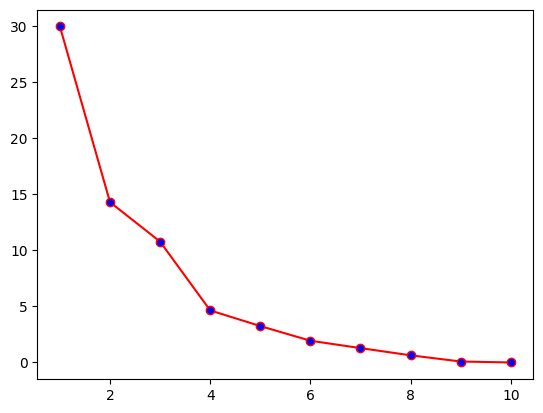

In [16]:
wcss=[]
for i in range(1,11):
    wcss.append(KMeans(n_clusters=i,random_state=42).fit(cluster_df).inertia_)
plt.plot(range(1,11),wcss,'r-o',mfc='b')
plt.show()

In [17]:
kmeans=KMeans(n_clusters=4,random_state=42)
prediction=kmeans.fit_predict(cluster_df.values)
print(prediction)

[1 1 2 0 3 0 3 1 3 1]


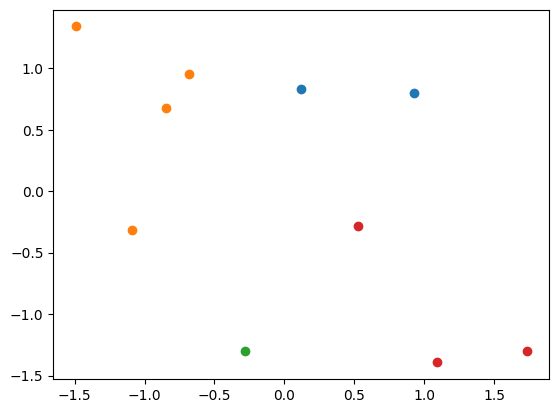

In [19]:
x=cluster_df.values
for i in range(4):
    plt.scatter(x[prediction==i,1],x[prediction==i,2])
plt.show()

In [20]:
cluster=AgglomerativeClustering(n_clusters=3)
prediction=cluster.fit_predict(cluster_df)
print(prediction)

[0 0 0 2 1 2 1 0 1 0]


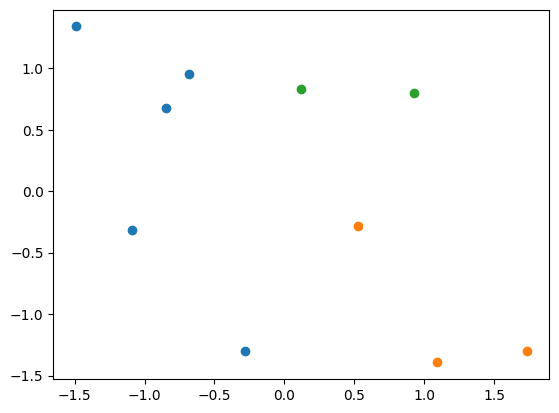

In [21]:
x=cluster_df.values
for i in range(4):
    plt.scatter(x[prediction==i,1],x[prediction==i,2])
plt.show()

In [22]:
from sklearn.metrics import silhouette_score

In [24]:
print(silhouette_score(cluster_df,prediction))

0.3399827084125601


In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [27]:
x=df[["Age","Income","SpendingScore"]]
target=df["BuysProduct"]
xtrain,xtest,ytrain,ytest=train_test_split(x,target,test_size=0.2)

In [29]:
model=SVC()
model.fit(xtrain,ytrain)

SVC()

In [30]:
ypred=model.predict(xtest)

In [31]:
model.score(xtest,ytest)

1.0

In [37]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(ytest,ypred,labels=[0,1])

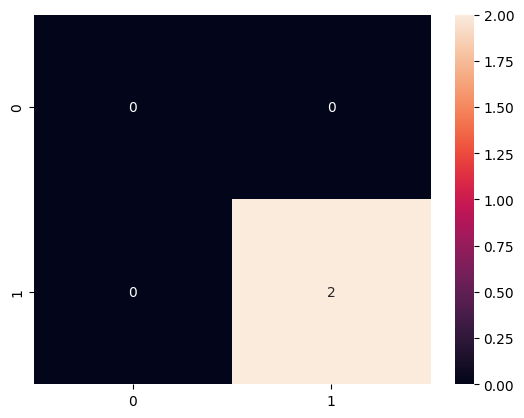

In [38]:
import seaborn as sns
sns.heatmap(cm,annot=True)
plt.show()

In [39]:
from sklearn.linear_model import Perceptron

In [40]:
model=Perceptron(eta0=0.1,random_state=42)

In [41]:
model.fit(xtrain,ytrain)

Perceptron(eta0=0.1, random_state=42)

In [42]:
ypred=model.predict(xtest)

In [43]:
model.score(xtrain,ytrain)

0.5

In [44]:
display(df.head())

,CustomerID,Age,Income,SpendingScore,BuysProduct
0,1,-1.256183,-1.087684,-0.312376,0
1,2,-0.850963,-0.684838,0.949142,0
2,3,-0.445742,-0.281992,-1.303568,1
3,4,0.499772,0.120854,0.828997,1
4,5,1.175139,0.523700,-0.282340,1


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [46]:
rf=RandomForestClassifier(random_state=42,n_jobs=-1)

In [47]:
params={"n_estimators":[20,30,50,100,200],"min_samples_leaf":[20,30,40,50,100],"max_depth":[2,3,5,10,20]}
gs=GridSearchCV(rf,params,n_jobs=-1,cv=4)

In [49]:
gs.fit(xtrain,ytrain)

C:\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=4.
  warnings.warn(


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [20, 30, 40, 50, 100],
                         'n_estimators': [20, 30, 50, 100, 200]})

In [54]:
model=gs.best_estimator_

In [55]:
ypred=model.predict(xtest)

In [57]:
gs.best_score_

0.625